**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Joshua Gamboa Calvo
*   MATRÍCULA: A01841021

---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [4]:
import pandas as pd
import numpy as np

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [5]:
# Carga de dataset
weather_df = pd.read_csv('/content/cleaned_weather.csv')

# Dimensionalidad e identificadores del df
print(weather_df.shape)
print(weather_df.columns)

(52696, 13)
Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='object')


In [6]:
# Renombramiento de columnas
new_names = {
    'timestamp': 'medicion',
    'p': 'presion_atmosferica',
    'T': 'temperatura_celsius',
    'Tpot': 'temperatura_kelvin',
    'rh': 'humedad_relativa',
    'VPact': 'presion_vapor',
    'sh': 'humedad_especifica',
    'H2OC': 'concentracion_vapor',
    'rho': 'densidad_aire',
    'wv': 'velocidad_viento',
    'wd': 'direccion_viento',
    'rain': 'precipitacion_total',
    'raining': 'duracion_lluvia'
}

weather_df.rename(columns=new_names, inplace=True)
weather_df.columns

Index(['medicion', 'presion_atmosferica', 'temperatura_celsius',
       'temperatura_kelvin', 'humedad_relativa', 'presion_vapor',
       'humedad_especifica', 'concentracion_vapor', 'densidad_aire',
       'velocidad_viento', 'direccion_viento', 'precipitacion_total',
       'duracion_lluvia'],
      dtype='object')

In [7]:
# Primeras 5 obervaciones
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [8]:
# Ultimas 5 observaciones
weather_df.tail()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [9]:
# Descripcion general del dataframe por columna en la cual se puede observar tanto cantidad de nulos como el tipo de cada columna

weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   medicion             52696 non-null  object 
 1   presion_atmosferica  52696 non-null  float64
 2   temperatura_celsius  52696 non-null  float64
 3   temperatura_kelvin   52696 non-null  float64
 4   humedad_relativa     52696 non-null  float64
 5   presion_vapor        52696 non-null  float64
 6   humedad_especifica   52696 non-null  float64
 7   concentracion_vapor  52696 non-null  float64
 8   densidad_aire        52696 non-null  float64
 9   velocidad_viento     52696 non-null  float64
 10  direccion_viento     52696 non-null  float64
 11  precipitacion_total  52696 non-null  float64
 12  duracion_lluvia      52696 non-null  int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 5.2+ MB


## ¿Hay valores faltantes en el dataframe?

Después de utilizar la función `info` se logra observar que no hay valores nulos ya que todas las columnas tienen una cuenta de valores no nulos igual a la cantidad total de observaciones `52696`.

In [10]:
# Actualización del tipo de la columna medicion a datetime y formateo requerido
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M')
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [11]:
# Agregar 2 columnas adicionales para fecha y hora
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time

weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [12]:
# Cuenta de unicos en el df por columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


In [13]:
# Identificacion de fila duplicada en columna mediciion
count = weather_df['medicion'].value_counts()
count[count > 1]

,count
medicion,
2020-05-12 06:00:00,2


Despues de contar la cantidad de ocurrencias de cada valor en la columan de `medicion` y el filtrado por valores con mas de una ocurrencia. Se logra identificar que la fecha `2020-12-05 06:00:00` cuanta con mas de una ocurrencia, por ende, es el valor duplicado.

In [14]:
duplicated_values = weather_df[weather_df['medicion'].duplicated(keep=False)].sort_values('medicion')
duplicated_values

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


In [15]:
# Verificar que las filas duplicadas son idénticas en todas las columnas
assert duplicated_values.duplicated(keep=False).all(), "Las filas duplicadas tienen valores distintos"

# Eliminar el registro duplicado (se conserva la primera aparición)
weather_df.drop_duplicates(inplace=True)

# Comprobar que ya no quedan mediciones duplicadas
assert weather_df['medicion'].duplicated().sum() == 0

# Mostrar que ya no existen mas de una fila con la medicion identificada
weather_df[weather_df['medicion'] == '2020-12-05 06:00:00']

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
48843,2020-12-05 06:00:00,968.42,-0.23,275.43,91.0,5.46,3.52,5.64,1233.49,0.74,140.8,0.0,0,2020-12-05,06:00:00


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [16]:
# Cuenta de unicos en el df por columna
weather_df.nunique()

,0
medicion,52695
presion_atmosferica,5052
temperatura_celsius,3680
temperatura_kelvin,3836
humedad_relativa,5494
presion_vapor,2059
humedad_especifica,1337
concentracion_vapor,2087
densidad_aire,14826
velocidad_viento,977


## ¿Por qué son 144 horas diferentes?

Porque si observamos la columna de `hora` podemos identificar el patrón con el cual se hacen las mediciones, el cual, es una medición cada 10 minutos.

Si tomamos esto en cuenta y sabiendo que un dia natural tiene 24 horas y se estan registrando 6 observaciones por hora (`00:00, 10:00, 20:00, 30:00, 40:00, 50:00`), realizando la formula `horas por dia x observaciones por hora` obtenemos la cantidad total de observaciones por dia la cual es `144`.

Formula: `24 * 6 = 144`.

Adicionalmente, este análisis se puede realizar de manera automatica con las funciones de `diff` y `mode` como se muestra a continuación.

In [17]:
frecuencia = weather_df['medicion'].sort_values().diff().mode()[0]
frecuencia

Timedelta('0 days 00:10:00')

In [18]:
# Se calcula el rango completo de mediciones esperado tomando la observación minima y maxima del dataset
rango_completo = pd.date_range(
    start=weather_df['medicion'].min(),
    end=weather_df['medicion'].max(),
    freq=frecuencia
)

# Se identifican los valores faltantes basdo en el rango esperado
faltantes = rango_completo.difference(weather_df['medicion'])
faltantes

DatetimeIndex(['2020-05-29 09:40:00', '2020-05-29 09:50:00',
               '2020-05-29 10:00:00', '2020-05-29 10:10:00',
               '2020-05-29 10:20:00', '2020-05-29 10:30:00',
               '2020-05-29 10:40:00', '2020-05-29 10:50:00',
               '2020-05-29 11:00:00'],
              dtype='datetime64[ns]', freq='10min')

In [19]:
# Conservar solo los registros del año 2020
weather_df = weather_df[weather_df['medicion'].dt.year == 2020]

# Eliminar la columna medicion
weather_df = weather_df.drop(columns='medicion')

weather_df.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [20]:
# Creacion de df con valores maximos diarios
indicadores_diarios = weather_df.drop(columns='hora').groupby('fecha').max()
indicadores_diarios.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
fecha,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0


In [21]:
# Extraccon de la medicion máxima de precipitacion
max_prec = indicadores_diarios.loc[indicadores_diarios['precipitacion_total'].idxmax()]

print(f"Máxima precipitación: {max_prec['precipitacion_total']} mm el {max_prec.name}")

Máxima precipitación: 11.2 mm el 2020-06-16


## ¿Cuál fue la máxima precipitación y a qué fecha pertenece?

Dado el análisis expuesto en la celda anterior, se identifica la fecha `2020-06-16` con una precipitacion de 11.2 mm como la máxima precipitacion de los datos del 2020.

In [22]:
# Ordenamiento por velocidad de viento y extraccion de los ultimos 3 valores (los mayores)
sorted_wind_speed = indicadores_diarios['velocidad_viento'].sort_values()
sorted_wind_speed.iloc[-3:]

,velocidad_viento
fecha,
2020-02-09,12.52
2020-02-16,13.00
2020-02-10,13.77


## ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?

Dado el analísis expuesto en la celda anterior, los 3 días con las velocidades de viento más altas fueron:
- 2020-02-10 con una velocidad de 13.77 m/s
- 2020-02-16 con una velocidad de 13.00 m/s
- 2020-02-09 con una velocidad de 12.52 m/s

In [23]:
# Filtrado por humedad relativa y temperatura celsius
humidity_temperature_analysis_df =  indicadores_diarios[
    (indicadores_diarios['humedad_relativa'] > 90) &
    (indicadores_diarios['temperatura_celsius'] > 30)
]

print(f"Un total de {len(humidity_temperature_analysis_df)} días rebasaron el 90% de humedad relativa y los 30° celsius")

Un total de 5 días rebasaron el 90% de humedad relativa y los 30° celsius


# ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
Dado el analísis expuesto en la celda anterior se identifican un total de 5 dias los cuales se rebasaron el 90% de humedad relativa y los 30 grados celsius.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [24]:
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


In [25]:
# Identificacición del tercer cuartil de la duración de la lluvia.

weather_df['duracion_lluvia'].quantile(0.75)

np.float64(0.0)

## ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?

La desviación estándar de la concentración de vapor es de `4.573267  mmol/mol`, dado que esta métrica nos indica que tan variables o dispersos estan los datos de la muestra. Podemos concluir que tiene una alta variabilidad ya que su coeficiente de variación (`desviacion estandar / promedio`) es de `39.632%`.

## ¿Cuál es la mediana de la presión atmosférica y qué significa?

La mediana de la presión atmosférica es de `992.98 mbar`, es decir, el valor central de los datos ordenados de menor a mayor. Esto indica que el 50% de las mediciones son iguales o menores a `992.98 mbar` y el otro 50% son iguales o mayores a este valor.

## ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

Dado el análisis de la celda anterior, se identifica que el tercer cuartil de la duración de la lluvia es de 0 segundos. Esto significa que al menos el 75% de las mediciones son iguales o menores a 0 segundos y, como la duración de la lluvia no puede ser negativa, en todas ellas la duración es exactamente 0, es decir, no llovió. Solo el 25% restante, o menos, registró lluvia durante el intervalo, lo que indica que la lluvia es un evento poco frecuente en el periodo analizado.

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

array([[<Axes: title={'center': 'presion_atmosferica'}>,
        <Axes: title={'center': 'temperatura_celsius'}>,
        <Axes: title={'center': 'temperatura_kelvin'}>],
       [<Axes: title={'center': 'humedad_relativa'}>,
        <Axes: title={'center': 'presion_vapor'}>,
        <Axes: title={'center': 'humedad_especifica'}>],
       [<Axes: title={'center': 'concentracion_vapor'}>,
        <Axes: title={'center': 'densidad_aire'}>,
        <Axes: title={'center': 'velocidad_viento'}>],
       [<Axes: title={'center': 'direccion_viento'}>,
        <Axes: title={'center': 'precipitacion_total'}>,
        <Axes: title={'center': 'duracion_lluvia'}>]], dtype=object)

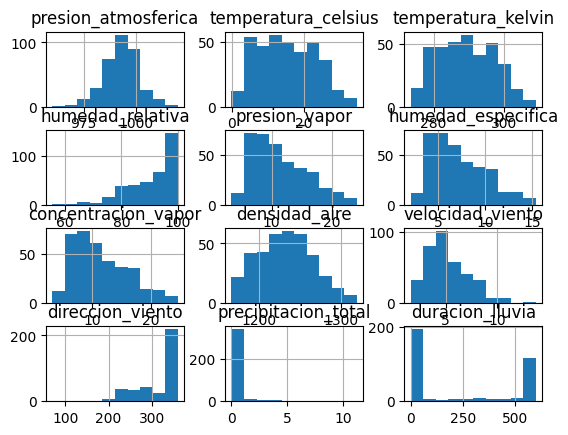

In [26]:
indicadores_diarios.hist()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [27]:
# Crear una copia de indiadores diarios
indicadores_mensuales = indicadores_diarios.copy()

# Crear la columan de mes
indicadores_mensuales["mes"] = pd.to_datetime(indicadores_mensuales.index).month_name()

indicadores_mensuales.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,mes
fecha,,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0,January
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0,January
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470,January
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600,January
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0,January


In [28]:
# Agrupar por mes mantieniendo humedad, temperatura y velcidad.
month_extract = ['humedad_relativa', 'temperatura_celsius', 'velocidad_viento']
indicadores_mensuales.groupby('mes', observed=True)[month_extract].mean()

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
April,80.938667,16.879667,4.997000
August,92.002581,26.097742,5.040323
December,97.510968,5.680000,4.817097
February,85.719655,8.962414,7.489655
January,89.776129,6.821290,5.031935
July,85.959355,24.336129,4.830323
June,94.256000,22.212000,5.296667
March,85.372903,9.683871,6.421290
May,87.464839,17.135484,4.865806


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [29]:
# Crear una copia de indiadores diarios con pivot table
indicadores_mensuales_pivot = indicadores_diarios.copy()

# Crear la columan de mes
indicadores_mensuales_pivot["mes"] = pd.to_datetime(indicadores_mensuales_pivot.index).month_name()

indicadores_mensuales_pivot = indicadores_mensuales_pivot.pivot_table(
    index='mes',
    values=month_extract,
    aggfunc='mean',
    observed=True
)

indicadores_mensuales_pivot

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
April,80.938667,16.879667,4.997000
August,92.002581,26.097742,5.040323
December,97.510968,5.680000,4.817097
February,85.719655,8.962414,7.489655
January,89.776129,6.821290,5.031935
July,85.959355,24.336129,4.830323
June,94.256000,22.212000,5.296667
March,85.372903,9.683871,6.421290
May,87.464839,17.135484,4.865806


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [30]:
# Uso de melt
indicadores_largo_melt = indicadores_mensuales_pivot.reset_index().melt(
    id_vars='mes',
    var_name='indicador',
    value_name='promedio'
)
indicadores_largo_melt

,mes,indicador,promedio
0,April,humedad_relativa,80.938667
1,August,humedad_relativa,92.002581
2,December,humedad_relativa,97.510968
3,February,humedad_relativa,85.719655
4,January,humedad_relativa,89.776129
5,July,humedad_relativa,85.959355
6,June,humedad_relativa,94.256000
7,March,humedad_relativa,85.372903
8,May,humedad_relativa,87.464839
9,November,humedad_relativa,96.983333


In [31]:
#Uso de stack

indicadores_largo_stack = indicadores_mensuales_pivot.stack()
indicadores_largo_stack

mes                           
April      humedad_relativa       80.938667
           temperatura_celsius    16.879667
           velocidad_viento        4.997000
August     humedad_relativa       92.002581
           temperatura_celsius    26.097742
           velocidad_viento        5.040323
December   humedad_relativa       97.510968
           temperatura_celsius     5.680000
           velocidad_viento        4.817097
February   humedad_relativa       85.719655
           temperatura_celsius     8.962414
           velocidad_viento        7.489655
January    humedad_relativa       89.776129
           temperatura_celsius     6.821290
           velocidad_viento        5.031935
July       humedad_relativa       85.959355
           temperatura_celsius    24.336129
           velocidad_viento        4.830323
June       humedad_relativa       94.256000
           temperatura_celsius    22.212000
           velocidad_viento        5.296667
March      humedad_relativa       85.372903
           temperatura_celsius     9.683871
           velocidad_viento        6.421290
May        humedad_relativa       87.464839
           temperatura_celsius    17.135484
           velocidad_viento        4.865806
November   humedad_relativa       96.983333
           temperatura_celsius    10.561667
           velocidad_viento        4.399000
October    humedad_relativa       96.950645
           temperatura_celsius    14.089355
           velocidad_viento        5.675484
September  humedad_relativa       97.570000
           temperatura_celsius    21.571667
           velocidad_viento        4.153333
dtype: float64

Aunque ambos métodos convierten el dataframe a formato largo con los mismos registros, lo hacen de forma distinta. `melt()` realiza una transformación controlada: mediante sus parámetros se define qué columna se conserva como identificador (`id_vars`) y cómo se nombran las nuevas columnas (`var_name` y `value_name`). Sin embargo, como trabaja solo con columnas y descarta el índice, fue necesario aplicar `reset_index()` para no perder el mes. El resultado es un DataFrame ordenado por indicador. En cambio, `stack()` aplica la conversión de forma automática sobre el nivel inferior de las columnas y mueve los nombres de los indicadores al índice, sin necesidad de especificar parámetros. El resultado es una Serie con un índice jerárquico (mes, indicador) ordenada por mes, que requiere pasos adicionales como `rename_axis()` y `reset_index()` para obtener el mismo formato que `melt()`. En resumen, `melt()` es más explícito y conveniente cuando se busca un DataFrame con columnas bien definidas, mientras que `stack()` resulta más directo cuando la información ya está organizada en el índice y las columnas.

---

**Declaración de uso de IA**

Anthropic. (2026). Claude (Claude Opus 5.5) [Modelo de lenguaje grande], utilizado para generación de código, depuración, explicación de conceptos estadísticos y de pandas, y revisión de la redacción de las interpretaciones. https://claude.ai/

---